# Syllable Usage Heatmap: CS vs. WMS

Computes per-animal syllable usage fractions at baseline (BSL) and 7 days post-injury (7DPI) in young male mice, then plots a heatmap of the **7DPI / BSL usage ratio** for each treatment group (CS, WMS). A ratio > 1 indicates increased usage post-injury; < 1 indicates suppression. Also exports a reference table mapping syllable IDs to human-readable behavioral labels.

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
try:
    from statannotations.Annotator import Annotator
except:
    !pip install statannotations
    from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt

## Setup

Imports, syllable-to-cluster mapping (`id_to_cluster`), and data loading. `id_to_cluster` assigns each of the 38 syllable IDs to a kinematic category (High/Low Velocity × High/Low Displacement).

In [ ]:
id_to_cluster = {
    0:  'High Vel, High Disp',
    1:  'Low Vel, High Disp',
    2:  'Low Vel, Low Disp',
    3:  'High Vel, Low Disp',
    4:  'High Vel, Low Disp',
    5:  'Low Vel, Low Disp',
    6:  'High Vel, High Disp',
    7:  'Low Vel, High Disp',
    8:  'Low Vel, High Disp',
    9:  'Low Vel, High Disp',
    10: 'Low Vel, High Disp',
    11: 'Low Vel, Low Disp',
    12: 'High Vel, Low Disp',
    13: 'High Vel, Low Disp',
    14: 'Low Vel, Low Disp',
    15: 'High Vel, Low Disp',
    16: 'High Vel, High Disp',
    17: 'Low Vel, High Disp',
    18: 'High Vel, High Disp',
    19: 'Low Vel, High Disp',
    20: 'High Vel, High Disp',
    21: 'High Vel, High Disp',
    22: 'Low Vel, High Disp',
    23: 'High Vel, Low Disp',
    24: 'Low Vel, Low Disp',
    25: 'High Vel, High Disp',
    26: 'High Vel, High Disp',
    27: 'Low Vel, Low Disp',
    28: 'High Vel, High Disp',
    29: 'High Vel, High Disp',
    30: 'Low Vel, Low Disp',
    31: 'Low Vel, Low Disp',
    32: 'High Vel, High Disp',
    33: 'Low Vel, Low Disp',
    34: 'High Vel, Low Disp',
    35: 'High Vel, Low Disp',
    36: 'Low Vel, High Disp',
    37: 'Low Vel, Low Disp',
}

In [ ]:
MODEL_PATH = Path('/mnt/g/Shared drives/llorente-lab/Moseq/AnalyzedData/Nature_Comms_Manuscript/')
MOSEQ_DF_PATH = MODEL_PATH / 'moseq_df.csv'
STATS_DF_PATH = MODEL_PATH / 'stats_df.csv'

moseq_df = pd.read_csv(MOSEQ_DF_PATH)
stats_df = pd.read_csv(STATS_DF_PATH)

print(moseq_df.shape)
print(stats_df.shape)

(20241328, 37)
(26976, 95)


In [ ]:
save_path = '/mnt/g/Shared drives/llorente-lab/Moseq/Manuscript/revision_resubmission/figures_revision_plots/Figure-1'
SAVE_PATH = Path(save_path)

In [ ]:
moseq_df = moseq_df[moseq_df['labels (usage sort)'] >= 0]
moseq_df.shape # make sure it's all okay

(20239642, 37)

In [ ]:
moseq_df['sex'].unique()

array(['Male', 'Female'], dtype=object)

## Data Filtering & Subset

Restricts analysis to **young male** mice to reduce age/sex confounds when comparing CS and WMS stroke responses.

In [ ]:
df = moseq_df[
    (moseq_df['age'] == 'young') &
    (moseq_df['sex'] == 'Male')
].copy()

## Usage Computation

`get_usage()` normalizes each animal's syllable counts as a fraction of total frames. `build_matrix()` pivots these into a (subjects × syllables) matrix for a given timepoint.

In [ ]:
def get_usage(data):
    total = len(data)
    counts = data['labels (usage sort)'].value_counts()
    return counts / total

records = []
for (subject, timepoint, treatment), grp in df[df['timepoint'].isin(['BSL', '7DPI'])].groupby(['SubjectName', 'timepoint', 'treatment']):
    usage = get_usage(grp)
    records.append({'SubjectName': subject, 'timepoint': timepoint, 'treatment': treatment, 'usage': usage})

records_df = pd.DataFrame(records)

In [ ]:
all_syllables = df['labels (usage sort)'].unique()
all_syllables = all_syllables[all_syllables >= 0]
pct99 = min(int(np.percentile(all_syllables, 99)), 37)
print(f"99th percentile syllable index: {pct99}")
syllable_range = list(range(0, pct99 + 1))

99th percentile syllable index: 37


In [ ]:
def build_matrix(records_df, tp):
    subset = records_df[records_df['timepoint'] == tp].set_index('SubjectName')
    mat = pd.DataFrame(index=subset.index, columns=syllable_range, dtype=float).fillna(0)
    for subject, row in subset.iterrows():
        usage = row['usage'].reindex(syllable_range).fillna(0)
        mat.loc[subject] = usage.values
    mat['treatment'] = subset['treatment']
    return mat

bsl_mat = build_matrix(records_df, 'BSL')
dpi_mat = build_matrix(records_df, '7DPI')

## Heatmap: 7DPI / BSL Usage Ratio

For each treatment group, computes mean usage at BSL and 7DPI, then takes the ratio. The heatmap (coolwarm, centered at 1) highlights which syllables are up- or down-regulated after stroke.

In [ ]:
rows = {}
for treatment in ['WMS', 'CS']:
    # Mean BSL usage across animals in this treatment group
    bsl_mean = bsl_mat[bsl_mat['treatment'] == treatment][syllable_range].mean(axis=0)
    # Mean 7DPI usage across animals in this treatment group
    dpi_mean = dpi_mat[dpi_mat['treatment'] == treatment][syllable_range].mean(axis=0)
    # Normalize
    rows[treatment] = dpi_mean / (bsl_mean + 1e-8)

heatmap_df = pd.DataFrame(rows)  # shape: (2, n_syllables)

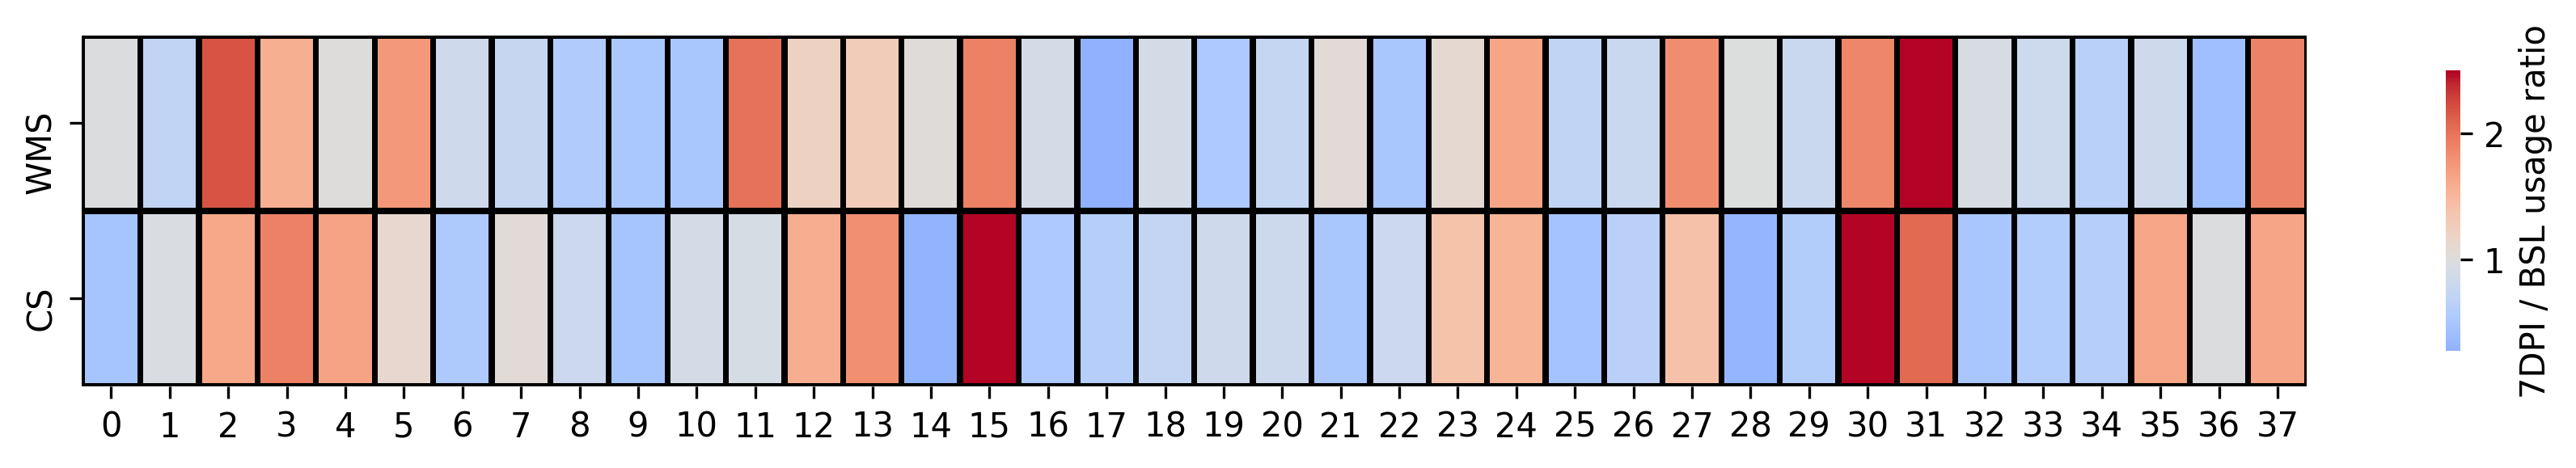

In [ ]:
fig, ax = plt.subplots(figsize=(12, 2))
fig.dpi = 300

sns.heatmap(
    heatmap_df.T,
    ax=ax,
    cmap='coolwarm',
    linewidth=1.5,
    center=1,
    vmin=vmin,
    vmax=2.5,
    linecolor='black',
    cbar_kws={'label': '7DPI / BSL usage ratio', 'shrink': 0.8},
    xticklabels=True,
    yticklabels=True
)

plt.tight_layout()
plt.savefig(SAVE_PATH/'WMS_vs_CS_Heatmap_with_Syll_IDs.pdf')
plt.show()

## Syllable Label Reference Table

Maps each syllable ID (0–37) to a descriptive behavioral label (e.g., Rear Up, Dart, Groom). Exported as both a PDF figure and a CSV for downstream reference.

In [ ]:
#hard-coded
syllable_labels = {
    0: 'Rear Up',
    1: 'Rear',
    2: 'Turn',
    3: 'Dart',
    4: 'Dart',
    5: 'Slow Turn',
    6: 'Rear On Wall',
    7: 'Walk',
    8: 'Rear Down',
    9: 'Look Up',
    10: 'Inch Forward',
    11: 'Turn',
    12: 'Dart',
    13: 'Dart',
    14: 'Slow Turn',
    15: 'Fast Turn',
    16: 'Rear Up',
    17: 'Slow Dart',
    18: 'Rear Up',
    19: 'Rear Down',
    20: 'Rear Up',
    21: 'Rear On Wall',
    22: 'Look Up',
    23: 'Fast Dart',
    24: 'Stop',
    25: 'Hold On Wall',
    26: 'Hold On Wall',
    27: 'Stop',
    28: 'Hold On Wall',
    29: 'Hold On Wall',
    30: 'Pause',
    31: 'Pause',
    32: 'Hold On Wall',
    33: 'Groom',
    34: 'Dart',
    35: 'Long Dart',
    36: 'Slow Dart',
    37: 'Stop',
}

In [ ]:
import matplotlib.patches as mpatches

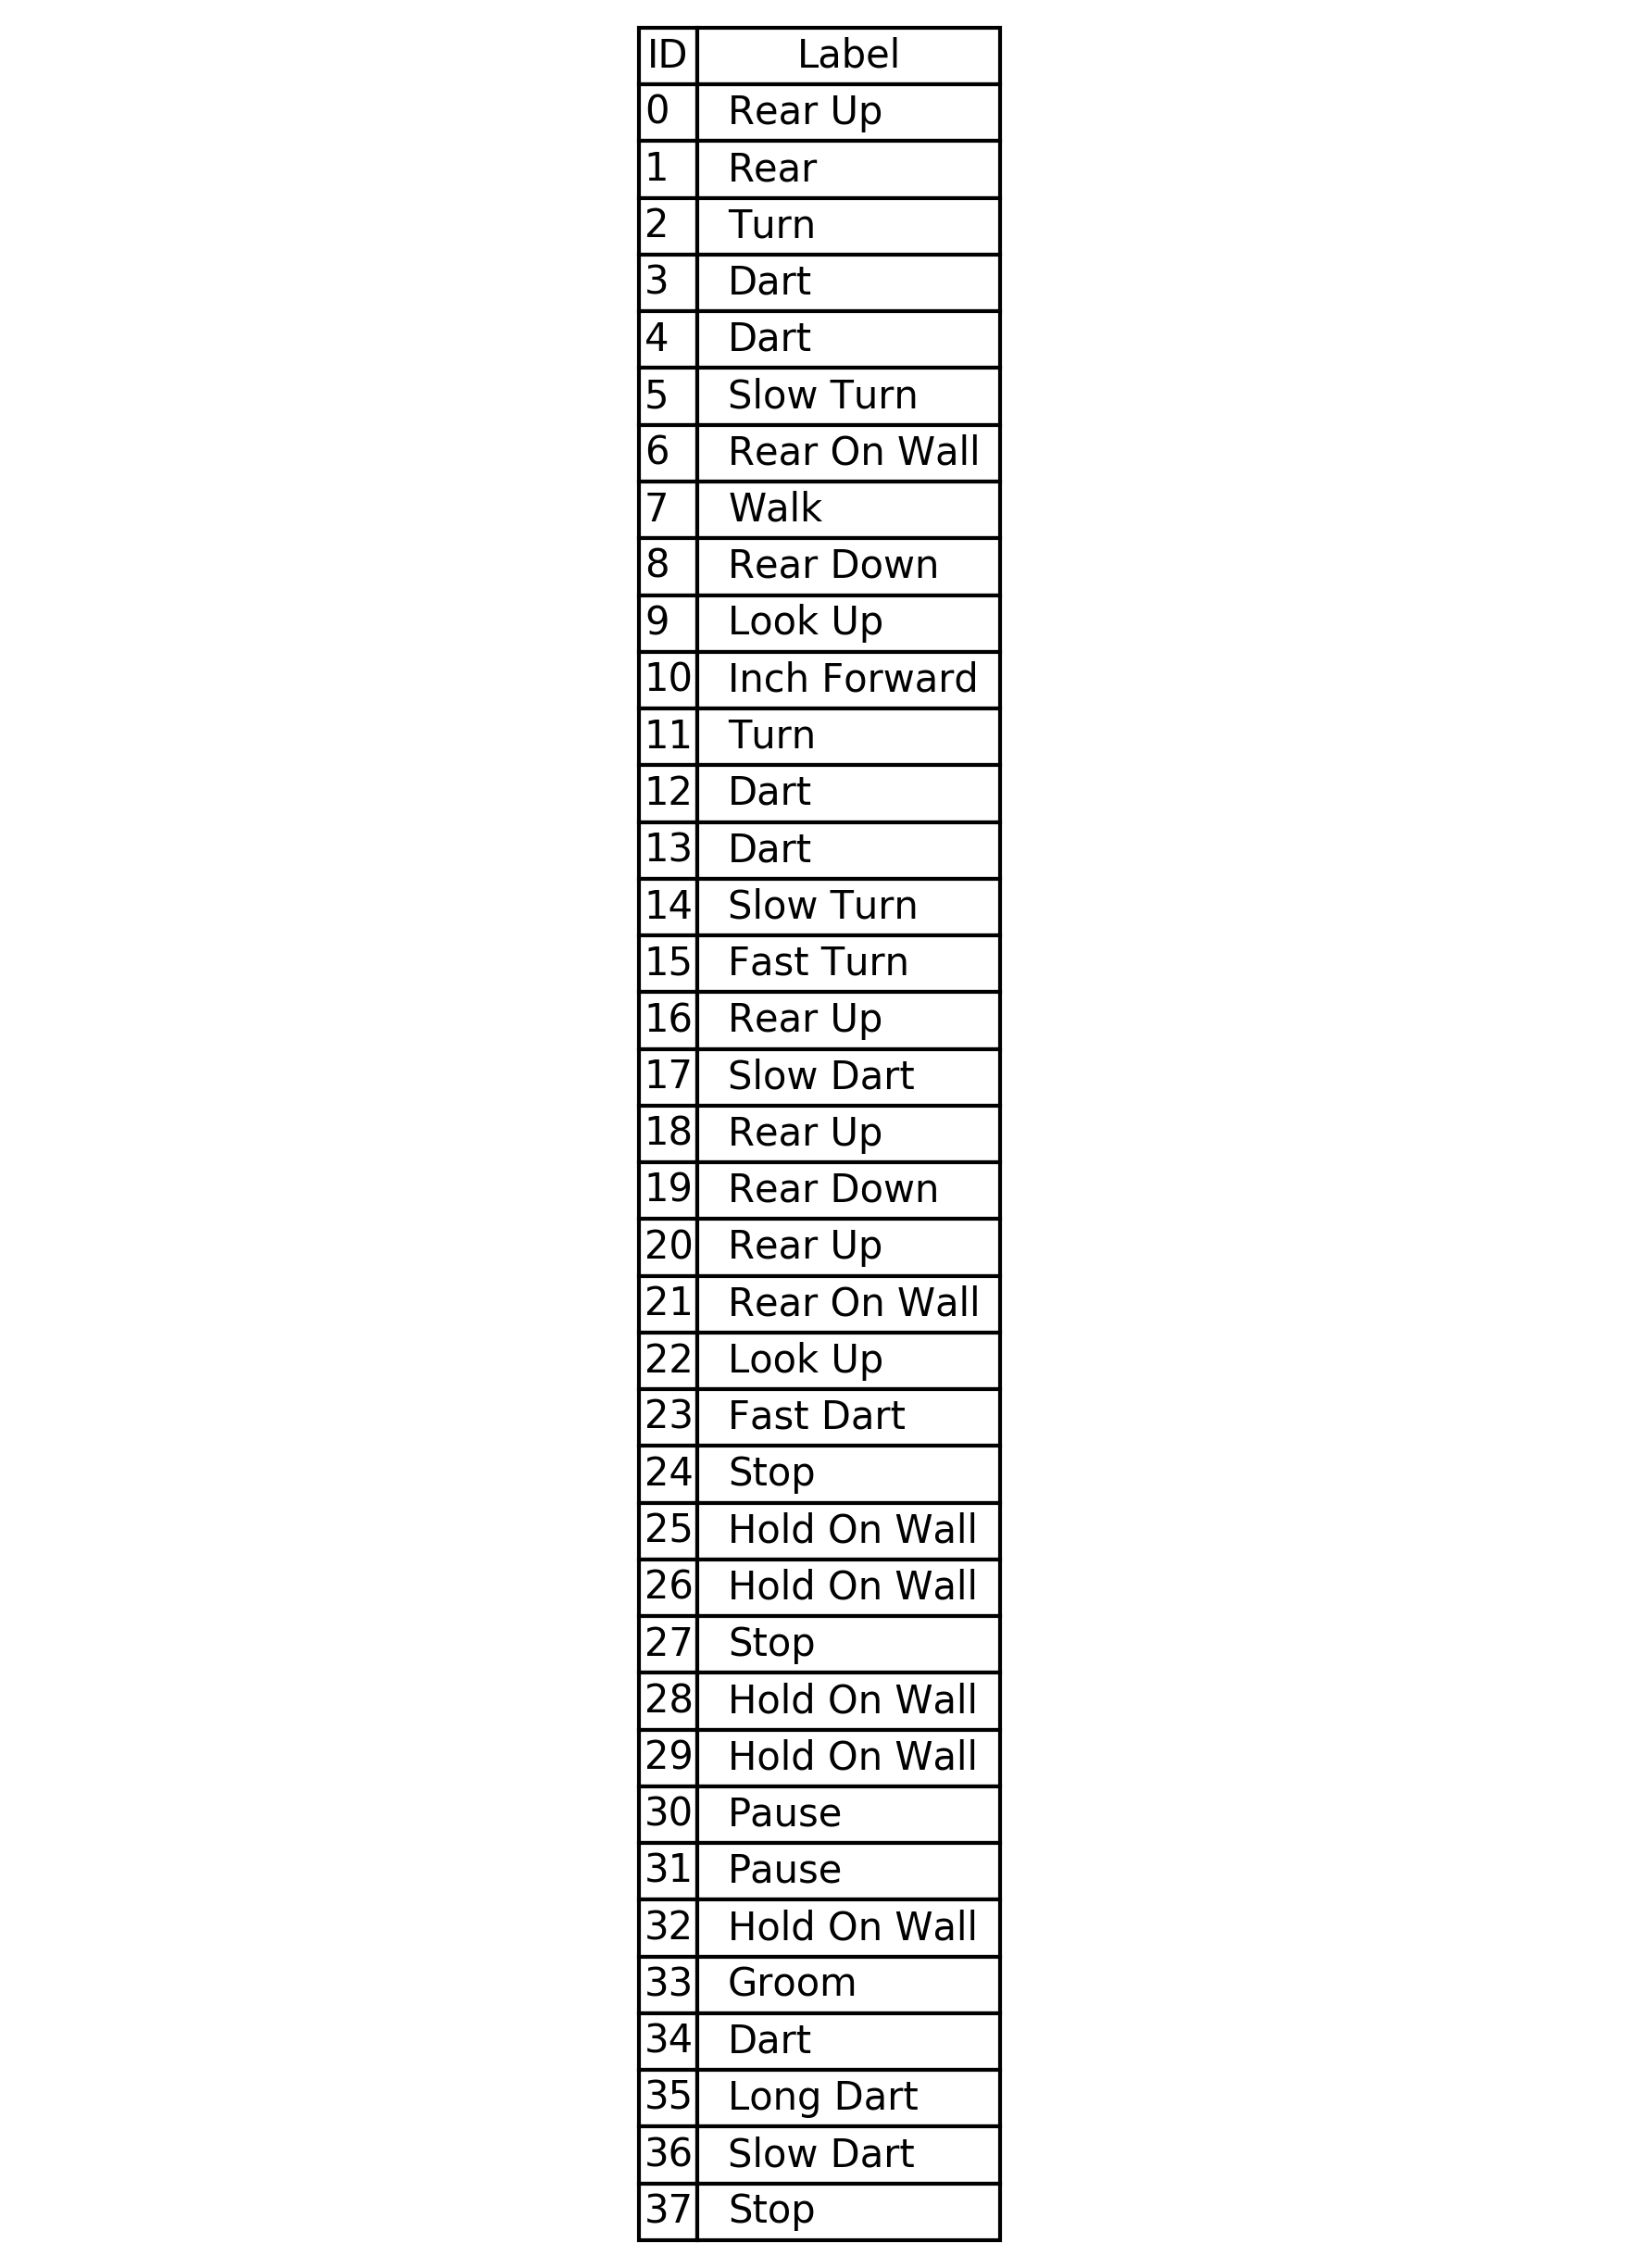

In [ ]:
fig, ax = plt.subplots()
fig.dpi = 300
ax.axis('off')

table_data = [[str(k), v] for k, v in sorted(syllable_labels.items())]
table = ax.table(
    cellText=table_data,
    colLabels=['ID', 'Label'],
    loc='center',
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width([0, 1])

plt.tight_layout()
plt.savefig(SAVE_PATH / 'syllable_to_id_label_mapping.pdf')
plt.show()

In [ ]:
syll_df = pd.DataFrame(table_data)
syll_df.to_csv(SAVE_PATH/'syllable_to_id_label_mapping.csv', index=False)